# Tutorial 04 — `FisherFlex`: forecasting from *your* n(z), footprint and depth

`fisherA2Z.Fisher` reproduces the published LSST 3&times;2pt forecast
([arXiv:2507.01374](https://arxiv.org/abs/2507.01374)), but it is hard-wired to that one
analysis: exactly 5 source bins built from the SRD `nzdist.txt`, a fixed on-disk SRD
covariance (so `fsky`, `n_eff` and `sigma_e` cannot be changed), and photo-z priors the
user has to derive somewhere else.

**`FisherFlex` answers the question `Fisher` cannot:** *what does my survey get, given my
n(z), my number densities, my footprint and my shape noise?* It keeps A2Z's physics — CCL
tracers, NLA intrinsic alignments with the Schechter luminosity function, linear galaxy
bias, the same $\ell$ grid, the same Fisher algebra and figure of merit — and replaces the
three rigid pieces:

| | `Fisher` | `FisherFlex` |
|---|---|---|
| n(z) | fixed 5-bin SRD | **any** n(z), any number of bins |
| covariance | fixed SRD file | **built** from `fsky`, `neff`, `sigma_e` |
| photo-z priors | supplied by the user | **derived** from n(z) realizations |

The photo-z model is chosen with `nz_model=`. The default, `'shift_stretch'`, keeps your
measured n(z) as the template and marginalizes over a shift and a stretch per bin;
`'gaussian_outlier'` is the A2Z Gaussian-core-plus-outlier parameterization. Section 2
covers both and shows why the default is the right one for an n(z) with no separable
outlier island.

This notebook walks through all three using the real **HSC Y1** n(z) posterior samples.

> **One caveat up front.** The covariance built here is **Gaussian only**. The SRD
> covariance used by `Fisher` also contains non-Gaussian and super-sample terms, so
> `FisherFlex` figures of merit come out *optimistically high* relative to the paper.
> That is a difference in the covariance, not a bug.

In [1]:
import time
import numpy as np
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d

from fisherA2Z.fisher_flex import FisherFlex
from fisherA2Z import nz_decomposition as nzd

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

---
## 1. Generate the n(z) and its realizations

The HSC Y1 photometric redshift distributions come as **Dirichlet concentration parameters**
$\alpha$, one file per tomographic bin, from the sampling in
`fisher_flex_data/hscy1_alpha_sampling/`. Drawing from `Dirichlet(alpha)` gives a
realization of n(z); the ensemble of draws encodes the redshift-distribution uncertainty.

The four bins are the HSC Y1 selections $z \in$ [0.3, 0.6], [0.6, 0.9], [0.9, 1.2], [1.2, 1.5].
Note this is **4 bins, not 5** — `FisherFlex` infers the number of tomographic bins from the
input, so nothing else has to change.

In [2]:
ALPHA_DIR = "fisher_flex_data/hscy1_alpha_sampling/alphas/"
ALPHA_FILES = [
    "result_photometry_0_3_0_6_alpha.dat",
    "result_photometry_0_6_0_9_alpha.dat",
    "alpha_result_0_9_1_2.dat",
    "alpha_result_1_2_1_5.dat",
]
BIN_LABELS = ["0.3 < z < 0.6", "0.6 < z < 0.9", "0.9 < z < 1.2", "1.2 < z < 1.5"]

N_REAL = 200                                 # realizations used to set the priors
z_grid = np.linspace(0.02, 3.0, 150)         # common grid; the alpha files stop at z < 2

rng = np.random.default_rng(42)
per_bin = []
for fname in ALPHA_FILES:
    alpha = np.loadtxt(ALPHA_DIR + fname)     # columns: z, alpha
    draws = rng.dirichlet(alpha[:, 1], size=N_REAL)
    draws /= np.trapz(draws, alpha[:, 0], axis=1)[:, None]
    # Each bin has its own z sampling, so interpolate onto the shared grid.
    on_grid = interp1d(alpha[:, 0], draws, kind="linear",
                       bounds_error=False, fill_value=0.0)(z_grid)
    on_grid = np.clip(on_grid, 0.0, None)
    per_bin.append(on_grid / np.trapz(on_grid, z_grid, axis=1)[:, None])

# FisherFlex wants (n_realizations, n_tomo, n_z).
nz_realizations = np.swapaxes(np.array(per_bin), 0, 1)
nz_source = nz_realizations.mean(axis=0)
nz_source /= np.trapz(nz_source, z_grid, axis=1)[:, None]

print("realizations:", nz_realizations.shape)
print("central n(z):", nz_source.shape)
print("mean redshift per bin:",
      np.round(np.trapz(nz_source * z_grid, z_grid, axis=1), 3))

realizations: (200, 4, 150)
central n(z): (4, 150)
mean redshift per bin: [0.464 0.745 1.048 1.325]


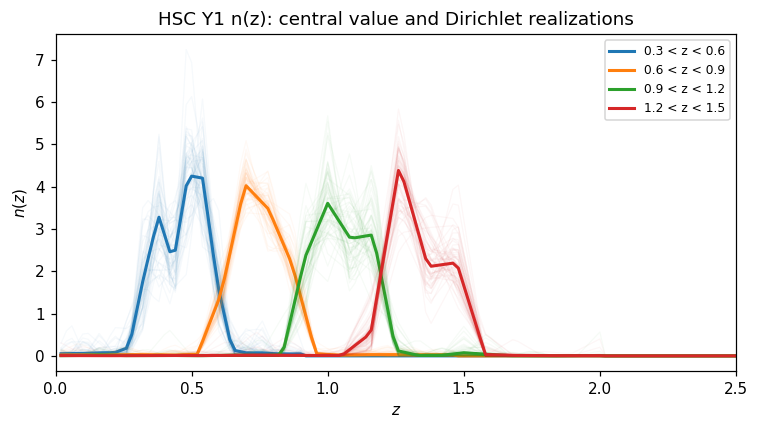

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
for b, label in enumerate(BIN_LABELS):
    color = f"C{b}"
    for r in range(60):
        ax.plot(z_grid, nz_realizations[r, b], color=color, alpha=0.04, lw=0.8)
    ax.plot(z_grid, nz_source[b], color=color, lw=2, label=label)
ax.set_xlim(0, 2.5)
ax.set_xlabel("$z$")
ax.set_ylabel("$n(z)$")
ax.set_title("HSC Y1 n(z): central value and Dirichlet realizations")
ax.legend(fontsize=8)
plt.tight_layout()

---
## 2. Turn the n(z) and its realizations into a photo-z model and a prior

Every Fisher forecast needs the n(z) to depend on a handful of nuisance parameters, so that
the uncertainty in the redshift distribution can be marginalized over. `FisherFlex` offers
two ways to get there, chosen with `nz_model=`.

The **default, `nz_model='shift_stretch'`**, keeps the *measured* n(z) as the template and
gives each bin two nuisance parameters — a shift and a stretch:

$$n_i(z;\, \delta z_i,\, s_i)\ \propto\
   n_i^{\rm obs}\!\left(z_{p,i} + \frac{z - z_{p,i} - \delta z_i}{s_i}\right),$$

with $z_{p,i}$ the fiducial mean of the bin. The mean of the modelled n(z) is then
$z_{p,i} + \delta z_i$ and its width is $s_i$ times the fiducial width. This is what DES,
KiDS and HSC actually use.

Two consequences are worth stating explicitly:

- **At the fiducial values $(\delta z_i, s_i) = (0, 1)$ the model returns the tabulated
  n(z) itself.** The fiducial data vector, the covariance and the derivatives are therefore
  all built on the measured n(z), not on a smooth fit to it.
- **There is no outlier fraction.** $f_{\rm out}$ is fixed at zero with a delta-function
  prior — which, with no outlier template to differentiate against, is the only consistent
  choice.

The estimator is closed form. The model is a location-scale family, so the shift and stretch
of a realization relative to the central n(z) are *exactly* the difference of the means and
the ratio of the standard deviations. No optimizer, no local minima, and — because both are
low-order moments — independent pixel noise in the realizations averages down over the grid
instead of being absorbed into the parameters.

In [4]:
t0 = time.time()
flex = FisherFlex(
    # -- the n(z) and its uncertainty ---------------------------------
    nz_source=nz_source,
    nz_realizations=nz_realizations,
    z_grid=z_grid,
    # -- the survey ---------------------------------------------------
    neff_source=[1.5, 1.5, 1.0, 1.0],   # arcmin^-2, per tomographic bin
    fsky=0.0364,                        # ~150 deg^2, HSC Y1
    sigma_e=0.26,                       # per-component ellipticity dispersion
    # -- the analysis -------------------------------------------------
    mode="3x2pt",                       # or '2x2pt' / 'cosmic_shear'
    nz_model="shift_stretch",           # the default; see below for the alternative
)
print(f"\n__init__ took {time.time() - t0:.1f} s (moments only, no CCL)")

Measuring the shift and stretch of 200 realizations ...

__init__ took 0.7 s (moments only, no CCL)


In [5]:
prior_sigma = np.sqrt(np.diagonal(flex.pz_prior_cov, axis1=1, axis2=2))
corr = flex.pz_prior_cov[:, 0, 1] / (prior_sigma[:, 0] * prior_sigma[:, 1])

print(f"{'bin':<16}{'z_pivot':>10}{'sigma_fid':>11}"
      f"{'s(dz)':>10}{'s(stretch)':>12}{'corr':>8}")
for b, label in enumerate(BIN_LABELS):
    print(f"{label:<16}{flex.pz_pivot[b]:>10.4f}{flex.pz_sigma[b]:>11.4f}"
          f"{prior_sigma[b, 0]:>10.4f}{prior_sigma[b, 1]:>12.4f}{corr[b]:>8.2f}")

bin                z_pivot  sigma_fid     s(dz)  s(stretch)    corr
0.3 < z < 0.6       0.4642     0.1031    0.0114      0.0953   -0.13
0.6 < z < 0.9       0.7455     0.1190    0.0099      0.1271    0.18
0.9 < z < 1.2       1.0481     0.1299    0.0178      0.2043    0.15
1.2 < z < 1.5       1.3253     0.1308    0.0192      0.2216   -0.44


Those are the numbers that go into the forecast: a shift prior of 0.010–0.019 in redshift
and a stretch prior of 10–22%, both read directly off the spread of the Dirichlet
realizations. The full $2\times2$ per-bin covariance is used, so the correlation in the last
column is carried through rather than thrown away.

The stretch prior is wide because `sigma_fid` here is the **rms width of the whole n(z)**,
tails included, and it is the tails that the Dirichlet draws move around most. It is not
directly comparable to the `sigma` of the Gaussian *core* fitted in the next subsection
(0.06–0.08), which describes only the peak.

The plot below is the check that matters — the fiducial model curve lies exactly on top of
the input n(z), because it *is* the input n(z). The shaded bands show what a $1\sigma$ shift
and a $1\sigma$ stretch actually do.

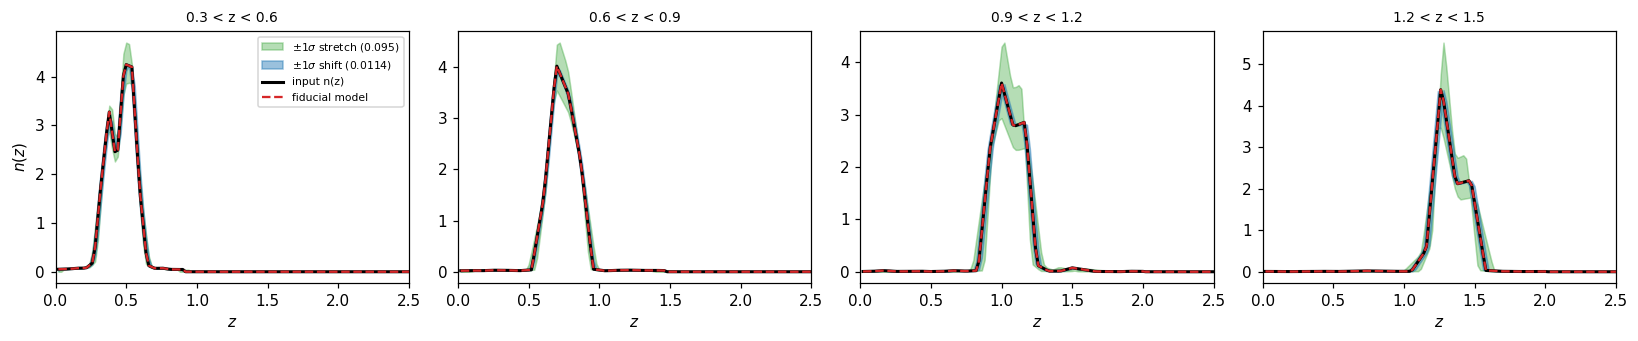

In [6]:
from fisherA2Z.nz_shift_stretch import shift_stretch_nz

fig, axes = plt.subplots(1, 4, figsize=(15, 3.2), sharex=True)
for b, (ax, label) in enumerate(zip(axes, BIN_LABELS)):
    fid = flex.nz_source_fid[b]
    pivot = flex.pz_pivot[b]
    s_dz, s_st = prior_sigma[b, 0], prior_sigma[b, 1]

    shifted = [shift_stretch_nz(z_grid, fid, k * s_dz, 1.0, pivot) for k in (-1, 1)]
    stretched = [shift_stretch_nz(z_grid, fid, 0.0, 1 + k * s_st, pivot) for k in (-1, 1)]

    ax.fill_between(z_grid, *stretched, color="C2", alpha=0.35,
                    label=rf"$\pm 1\sigma$ stretch ({s_st:.3f})")
    ax.fill_between(z_grid, *shifted, color="C0", alpha=0.45,
                    label=rf"$\pm 1\sigma$ shift ({s_dz:.4f})")
    ax.plot(z_grid, nz_source[b], "k-", lw=2, label="input n(z)")
    ax.plot(z_grid, flex.nz_source_fid[b], "--", color="C3", lw=1.5,
            label="fiducial model")

    ax.set_title(label, fontsize=9)
    ax.set_xlim(0, 2.5)
    ax.set_xlabel("$z$")
axes[0].set_ylabel("$n(z)$")
axes[0].legend(fontsize=7)
plt.tight_layout()

In [7]:
# The defining property, checked rather than asserted.
model_fid = flex._model().source_nz(flex.fid)
print("max |model(fiducial) - measured n(z)| / max n(z) =",
      f"{np.abs(model_fid - flex.nz_source_fid).max() / flex.nz_source_fid.max():.2e}")

max |model(fiducial) - measured n(z)| / max n(z) = 2.03e-16


---
## 3. `compute()` — derivatives and covariance

This is the slow step, and the only one that touches CCL. It does three things:

1. evaluates the fiducial data vector, ordered **`[cosmic shear, GGL, clustering]`**;
2. builds the **analytic Gaussian covariance** from `fsky`, `neff` and `sigma_e`;
3. differentiates the whole data vector with respect to every parameter.

The parameter vector here is 29-dimensional: 7 cosmological ($\Omega_m, \sigma_8, n_s, w_0,
w_a, \Omega_b, h$) + 4 intrinsic-alignment + 2&times;4 photo-z + 10 galaxy-bias, the last
group belonging to the default LSST Y10 lens sample (10 bins over $0.2 < z < 1.2$), which
you can replace entirely via `lens_nz=`. (Under `nz_model='gaussian_outlier'` it would be
33: three photo-z parameters per bin instead of two.)

Derivatives are computed **in parallel** by default (one process per parameter). The results
are bitwise identical to the serial path, so this is free speed.

> `save=` writes everything to a compressed `.npz`. The file in this repo was produced by
> exactly this call, so re-running the notebook skips the computation entirely.

In [8]:
NPZ = "fisher_flex_data/hscy1_3x2pt.npz"

import os
t0 = time.time()
if os.path.exists(NPZ):
    flex.compute(precompute=NPZ)
    print(f"loaded precomputed arrays in {time.time() - t0:.1f} s")
else:
    flex.compute(save=NPZ, parallel=True)
    print(f"computed in {time.time() - t0:.1f} s")

print(f"\ndata vector : {flex.data_vector.shape}   (n_blocks, n_ell)")
print(f"derivatives : {flex.deriv.shape}   (n_par, n_blocks, n_ell)")
print(f"covariance  : {flex.cov_blocks.shape}   (n_ell, n_blocks, n_blocks)")

Loaded precomputed derivatives and covariance from fisher_flex_data/hscy1_3x2pt.npz
loaded precomputed arrays in 0.0 s

data vector : (35, 20)   (n_blocks, n_ell)
derivatives : (29, 35, 20)   (n_par, n_blocks, n_ell)
covariance  : (20, 35, 35)   (n_ell, n_blocks, n_blocks)


The covariance is stored **block-diagonal in $\ell$**, which it exactly is for a Gaussian
covariance — not as a dense `(n_data, n_data)` matrix. That is what makes `forecast()` cost
microseconds: the Fisher sum becomes a few dozen independent small Cholesky solves,

$$F = \sum_\ell D_\ell[{\rm mask}]^{\!\top}\, {\rm Cov}_\ell[{\rm mask},{\rm mask}]^{-1}\, D_\ell[{\rm mask}],$$

and, crucially, storing the **covariance rather than its inverse** is what lets scale cuts be
applied *after* the fact — since $C^{-1}[{\rm mask}] \ne (C[{\rm mask}])^{-1}$.

In [9]:
slices = flex.layout.probe_block_slices()
for probe, name in [("cs", "cosmic shear"), ("ggl", "galaxy-galaxy lensing"),
                    ("gc", "galaxy clustering")]:
    sl = slices[probe]
    print(f"{name:<24} blocks {sl.start:>3}-{sl.stop - 1:<3} "
          f"({sl.stop - sl.start:>2} bin pairs)")
print(f"\nGGL pairs kept (mean z_source > mean z_lens + 0.3): {len(flex.ggl_pairs)}")

cosmic shear             blocks   0-9   (10 bin pairs)
galaxy-galaxy lensing    blocks  10-24  (15 bin pairs)
galaxy clustering        blocks  25-34  (10 bin pairs)

GGL pairs kept (mean z_source > mean z_lens + 0.3): 15


---
## 4. `forecast()` — fast, repeatable, with scale cuts

`forecast()` is pure linear algebra on the cached arrays — no CCL, no re-differentiation.
The defaults are the A2Z/SRD scale cuts: $\ell \le 3000$ for cosmic shear, and
$\ell_{\max} = k_{\max}\,\chi(z_{\rm eff})\,h - 0.5$ with $k_{\max} = 0.3\,h/{\rm Mpc}$
for the two probes involving galaxy clustering.

Because it is fast, exploring cuts is cheap.

In [10]:
res = flex.forecast()
print(f"data points used: {res.n_data_used}\n")
print(res.summary(["omega_m", "sigma_8", "n_s", "w_0", "w_a", "omega_b", "h"]))

data points used: 378

parameter         fiducial       sigma       prior
omega_m             0.3156    0.022829        0.15
sigma_8              0.831    0.025536         0.2
n_s                 0.9645    0.034495         0.2
w_0                     -1     0.10099         0.8
w_a                      0     0.10384         1.3
omega_b              0.049   0.0028736       0.003
h                   0.6727    0.051037       0.125


In [11]:
s8, s8_err = res.s8()
print(f"S_8 = {s8:.4f} +/- {s8_err:.4f}")

S_8 = 0.8523 +/- 0.0115


In [12]:
# A tighter shear cut removes data, so every constraint must loosen.
res_cut = flex.forecast(ell_max_cs=1500.0)

print(f"{'':<22}{'default':>12}{'ell_max_cs=1500':>18}")
print(f"{'data points':<22}{res.n_data_used:>12}{res_cut.n_data_used:>18}")
for p in ["omega_m", "sigma_8", "w_0", "w_a"]:
    print(f"{'sigma(' + p + ')':<22}{res.sigma(p):>12.4f}{res_cut.sigma(p):>18.4f}")

                           default   ell_max_cs=1500
data points                    378               358
sigma(omega_m)              0.0228            0.0231
sigma(sigma_8)              0.0255            0.0262
sigma(w_0)                  0.1010            0.1013
sigma(w_a)                  0.1038            0.1042


In [13]:
# Individual probes, for comparison. `probes=` masks whole blocks out.
for label, kw in [("3x2pt", {}),
                  ("cosmic shear only", {"probes": ["cs"]}),
                  ("2x2pt (GGL + clustering)", {"probes": ["ggl", "gc"]})]:
    r = flex.forecast(**kw)
    print(f"{label:<26} n_data={r.n_data_used:>4}  "
          f"sigma(S8)={r.s8()[1]:.4f}  FoM(w0,wa)={r.fom('w_0', 'w_a'):8.2f}")

3x2pt                      n_data= 378  sigma(S8)=0.0115  FoM(w0,wa)=  284.36
cosmic shear only          n_data= 150  sigma(S8)=0.0213  FoM(w0,wa)=  111.30
2x2pt (GGL + clustering)   n_data= 228  sigma(S8)=0.0244  FoM(w0,wa)=    6.00


---
## 5. Contours and figures of merit

The figure of merit is the paper's definition, $ {\rm FoM} = 1/\sqrt{\det {\rm Cov}_{2\times2}}$,
available for **any** pair of parameters via `result.fom(p1, p2)`.

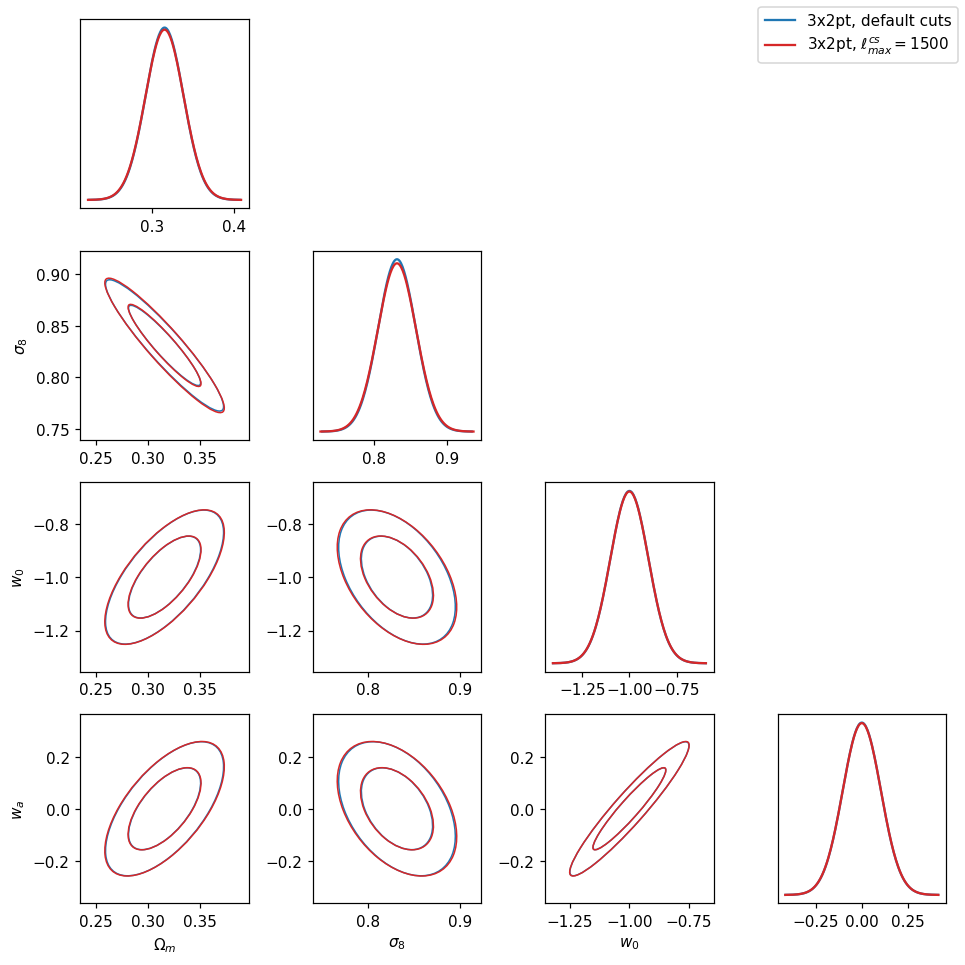

In [14]:
params = ["omega_m", "sigma_8", "w_0", "w_a"]
fig = res.corner(params, color="C0", label="3x2pt, default cuts")
fig = res_cut.corner(params, color="C3", label="3x2pt, $\\ell_{max}^{cs}=1500$", fig=fig)
fig.legend(loc="upper right", fontsize=10)
plt.show()

In [15]:
print(f"{'figure of merit':<28}{'default':>12}{'ell_max_cs=1500':>18}")
for p1, p2 in [("omega_m", "sigma_8"), ("w_0", "w_a")]:
    name = f"FoM({p1}, {p2})"
    print(f"{name:<28}{res.fom(p1, p2):>12.2f}{res_cut.fom(p1, p2):>18.2f}")

figure of merit                  default   ell_max_cs=1500
FoM(omega_m, sigma_8)            4700.68           4526.47
FoM(w_0, w_a)                     284.36            283.15


---
## Summary

```python
flex = FisherFlex(nz_source, nz_realizations, z_grid,   # your n(z) + its uncertainty
                  neff_source, fsky, sigma_e)           # your survey
flex.compute(save="my_forecast.npz")                    # slow, once
res = flex.forecast(ell_max_cs=3000)                    # fast, as often as you like
res.fom("w_0", "w_a")
```

Three things worth remembering:

- **The photo-z prior is derived, not assumed** — and with the default shift-and-stretch
  model it is derived from moments, which are stable against the pixel noise in the
  realizations. Run `prior_stability_report` anyway; a monotonic trend means the prior is
  measuring your sampling grid rather than your survey.
- **The covariance is Gaussian only.** No non-Gaussian or super-sample terms, so these FoMs
  are optimistic relative to the SRD-covariance numbers in the paper.
- **`compute()` once, `forecast()` many times.** Scale cuts, probe combinations and dropped
  parameters are all post-processing; none of them require redoing the derivatives.

`FisherFlex` also fixes two internal inconsistencies in `Fisher` (the IA luminosity function
now follows the varied cosmology, and $\partial/\partial\Omega_b$ is taken at fixed
$\Omega_m$). Pass `ia_lf_cosmo='fiducial'` and `omega_b_convention='a2z'` to reproduce the
published behaviour exactly.